In [15]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import pandas as pd
import os
import kagglehub
from scipy.signal import find_peaks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

path = kagglehub.dataset_download("rashikrahmanpritom/plant-disease-recognition-dataset")
print("Dataset path:", path)

Dataset path: /Users/jack.corley/.cache/kagglehub/datasets/rashikrahmanpritom/plant-disease-recognition-dataset/versions/1


In [16]:
def gen_color_hist(img):
    img_array = np.array(img.convert('RGB'))
    red_hist, _ = np.histogram(img_array[:, :, 0].flatten(), bins=256, range=(0, 256))
    green_hist, _ = np.histogram(img_array[:, :, 1].flatten(), bins=256, range=(0, 256))
    blue_hist, _ = np.histogram(img_array[:, :, 2].flatten(), bins=256, range=(0, 256))
    return {'red': red_hist, 'green': green_hist, 'blue': blue_hist}

def calculate_mean(histogram):
    return np.sum(np.arange(256) * histogram) / np.sum(histogram)

def calculate_std(histogram):
    mean = calculate_mean(histogram)
    variance = np.sum(((np.arange(256) - mean) ** 2) * histogram) / np.sum(histogram)
    return np.sqrt(variance)

def calculate_skewness(histogram):
    mean = calculate_mean(histogram)
    std = calculate_std(histogram)
    if std == 0:
        return 0
    return np.sum((((np.arange(256) - mean) / std) ** 3) * histogram) / np.sum(histogram)

def calculate_median(histogram):
    cumulative = np.cumsum(histogram)
    return float(np.argmax(cumulative >= np.sum(histogram) / 2.0))

def calculate_entropy(histogram):
    probabilities = (histogram + 1e-10) / np.sum(histogram)
    return -np.sum(probabilities * np.log2(probabilities))

def calculate_peak_count(histogram):
    peaks, _ = find_peaks(histogram, prominence=0.05 * np.max(histogram))
    return len(peaks)

def extract_histogram_features(histogram_data):
    features = {}
    for channel in ['red', 'green', 'blue']:
        histogram = histogram_data[channel]
        features[f'{channel}_mean'] = calculate_mean(histogram)
        features[f'{channel}_std'] = calculate_std(histogram)
        features[f'{channel}_skewness'] = calculate_skewness(histogram)
        features[f'{channel}_median'] = calculate_median(histogram)
        features[f'{channel}_entropy'] = calculate_entropy(histogram)
        features[f'{channel}_peak_count'] = calculate_peak_count(histogram)
    return features

In [ ]:
def load_and_extract_features(path, dataset_type='Train', classes=['Healthy', 'Powdery', 'Rust']):
    all_features = []
    all_labels = []
    
    for class_name in classes:
        print(f"Processing {class_name}...")
        class_path = os.path.join(path, dataset_type, dataset_type, class_name)
        img_files = os.listdir(class_path)
        
        for filename in img_files:
            img = Image.open(os.path.join(class_path, filename))
            hist_data = gen_color_hist(img)
            features = extract_histogram_features(hist_data)
            all_features.append(features)
            all_labels.append(class_name)
        
        print(f"  Loaded {len([l for l in all_labels if l == class_name])} images")
    
    feature_names = sorted(all_features[0].keys())
    X = np.array([[f[name] for name in feature_names] for f in all_features])
    y = np.array(all_labels)
    

    return X, y, feature_names

X_train_full, y_train_full, feature_names = load_and_extract_features(path)

Processing Healthy...
  Loaded 458 images
Processing Powdery...
  Loaded 430 images
Processing Rust...
  Loaded 434 images

Total: 1322 images, 18 features



In [18]:
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"Training: {len(X_train)} | Validation: {len(X_val)}")

Training: 1057 | Validation: 265


In [19]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train_encoded)
y_pred_rf = rf_model.predict(X_val_scaled)
acc_rf = accuracy_score(y_val_encoded, y_pred_rf)
print(f"Random Forest: {acc_rf:.4f}")

# SVM
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model.fit(X_train_scaled, y_train_encoded)
y_pred_svm = svm_model.predict(X_val_scaled)
acc_svm = accuracy_score(y_val_encoded, y_pred_svm)
print(f"SVM: {acc_svm:.4f}")

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train_encoded)
y_pred_lr = lr_model.predict(X_val_scaled)
acc_lr = accuracy_score(y_val_encoded, y_pred_lr)
print(f"Logistic Regression: {acc_lr:.4f}")

Random Forest: 0.7774
SVM: 0.8038
Logistic Regression: 0.7660


              Model  Accuracy
                SVM  0.803774
      Random Forest  0.777358
Logistic Regression  0.766038


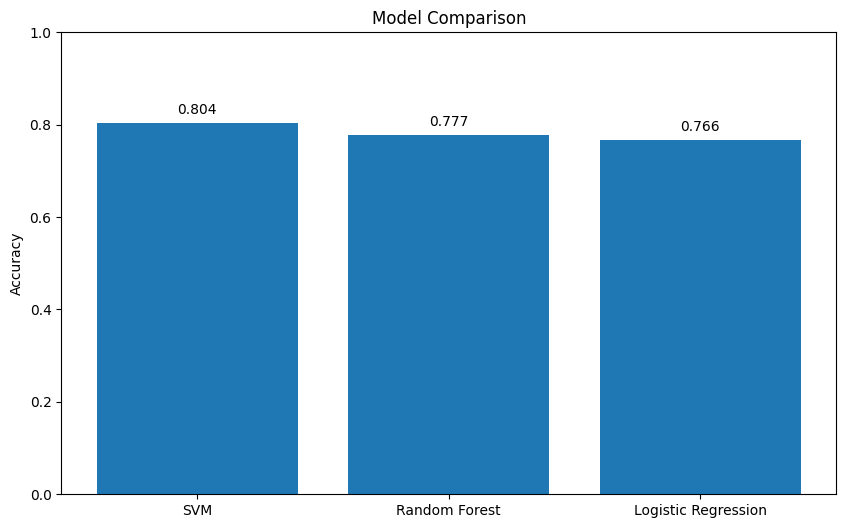

In [20]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'SVM', 'Logistic Regression'],
    'Accuracy': [acc_rf, acc_svm, acc_lr]
}).sort_values('Accuracy', ascending=False)

print(results.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.bar(results['Model'], results['Accuracy'])
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.ylim([0, 1])
for i, (model, acc) in enumerate(zip(results['Model'], results['Accuracy'])):
    plt.text(i, acc + 0.02, f'{acc:.3f}', ha='center')
plt.show()

              precision    recall  f1-score   support

     Healthy       0.79      0.80      0.80        92
     Powdery       0.73      0.78      0.75        86
        Rust       0.82      0.75      0.78        87

    accuracy                           0.78       265
   macro avg       0.78      0.78      0.78       265
weighted avg       0.78      0.78      0.78       265



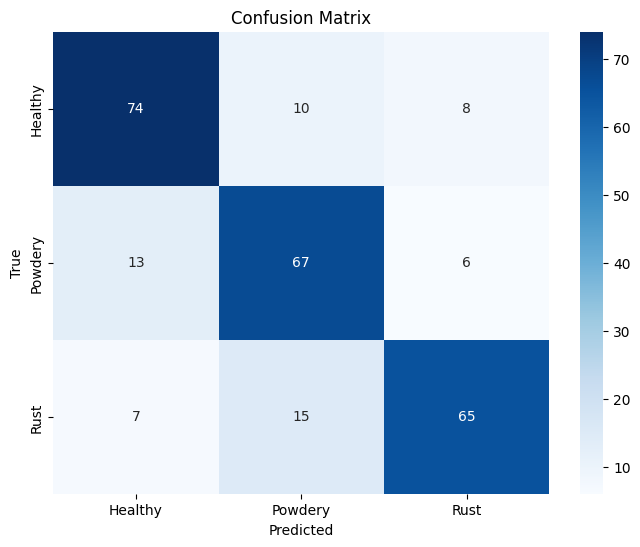

In [21]:
print(classification_report(y_val_encoded, y_pred_rf, target_names=label_encoder.classes_))

cm = confusion_matrix(y_val_encoded, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.ylabel('True')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

       Feature  Importance
    green_mean    0.123036
     blue_mean    0.102325
      red_mean    0.092997
    red_median    0.087511
   blue_median    0.071708
  green_median    0.070005
 blue_skewness    0.054411
  red_skewness    0.050780
green_skewness    0.044991
 green_entropy    0.044595


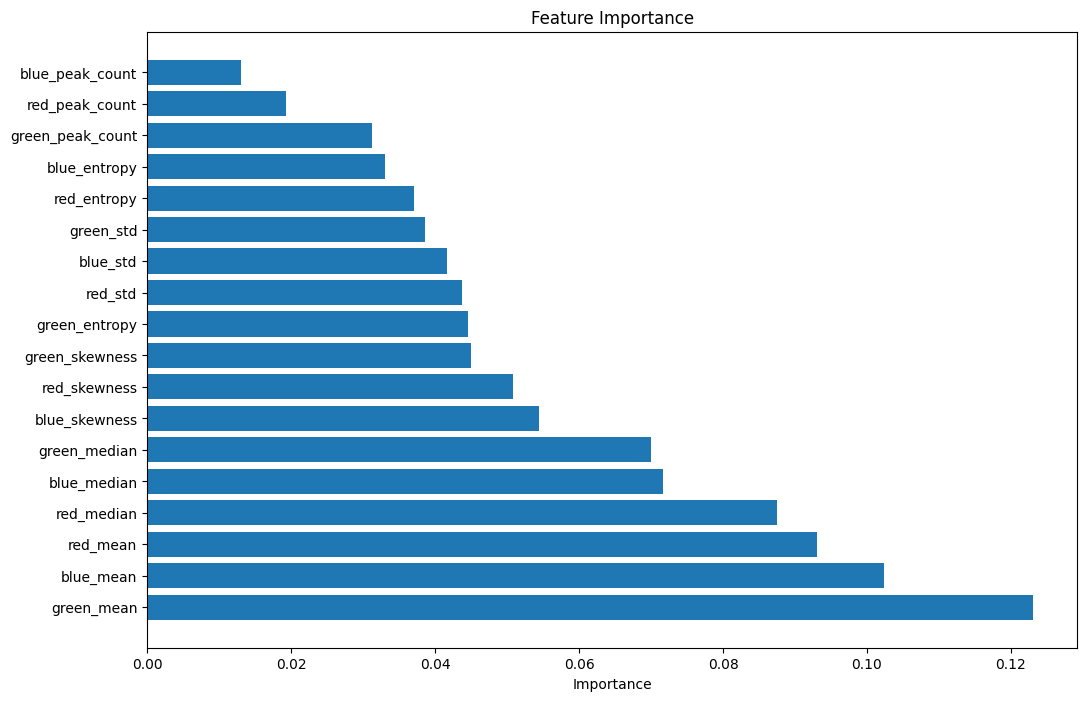

In [22]:
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance_df.head(10).to_string(index=False))

plt.figure(figsize=(12, 8))
plt.barh(range(len(feature_names)), importance_df['Importance'])
plt.yticks(range(len(feature_names)), importance_df['Feature'])
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.show()

Processing Healthy...
  Loaded 50 images
Processing Powdery...
  Loaded 50 images
Processing Rust...
  Loaded 50 images

Total: 150 images, 18 features

Test Accuracy: 0.6800

              precision    recall  f1-score   support

     Healthy       0.62      0.72      0.67        50
     Powdery       0.68      0.72      0.70        50
        Rust       0.77      0.60      0.67        50

    accuracy                           0.68       150
   macro avg       0.69      0.68      0.68       150
weighted avg       0.69      0.68      0.68       150



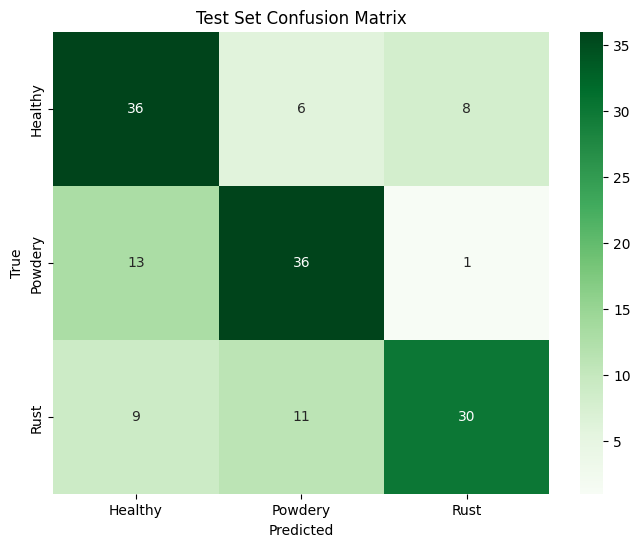

In [23]:
X_test, y_test, _ = load_and_extract_features(path, dataset_type='Test')

y_test_encoded = label_encoder.transform(y_test)
X_test_scaled = scaler.transform(X_test)
y_pred_test = rf_model.predict(X_test_scaled)

test_acc = accuracy_score(y_test_encoded, y_pred_test)
print(f"Test Accuracy: {test_acc:.4f}\n")
print(classification_report(y_test_encoded, y_pred_test, target_names=label_encoder.classes_))

cm_test = confusion_matrix(y_test_encoded, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.ylabel('True')
plt.xlabel('Predicted')
plt.title('Test Set Confusion Matrix')
plt.show()